In [ ]:
#environment setup and artifacts loading
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

shap.initjs() #initializing JavaScript visualization library for SHAP

model=joblib.load("../models/churn_model.pkl")
metadata=joblib.load("../models/model_metadata.pkl")
X_test= pd.read_csv("../data/X_test.csv")
y_test= pd.read_csv("../data/y_test.csv").squeeze("columns")

print(f"Loaded test records: {X_test.shape}")
print(f"Calibrated decision cutoff: {metadata['optimal_threshold']}")
print(f"Total features evaluated: {len(metadata['feature_names'])}")

Loaded test records: (1409, 35)
Calibrated decision cutoff: 0.35
Total features evaluated: 35


In [7]:
#TreeExplainer initialization and SHAP calculation
explainer=shap.TreeExplainer(model) #initializing TreeExplainer on trained xgboost estimator

#compute SHAP Explanation object for test set
shap_values=explainer(X_test) #outputs raw log-odds (margin output) for class 1 (churn)

print(f"SHAP values matrix dimensions: {shap_values.values.shape}")
print(f"Base expected values (log-odds): {explainer.expected_value:.4f}")

SHAP values matrix dimensions: (1409, 35)
Base expected values (log-odds): -1.0227


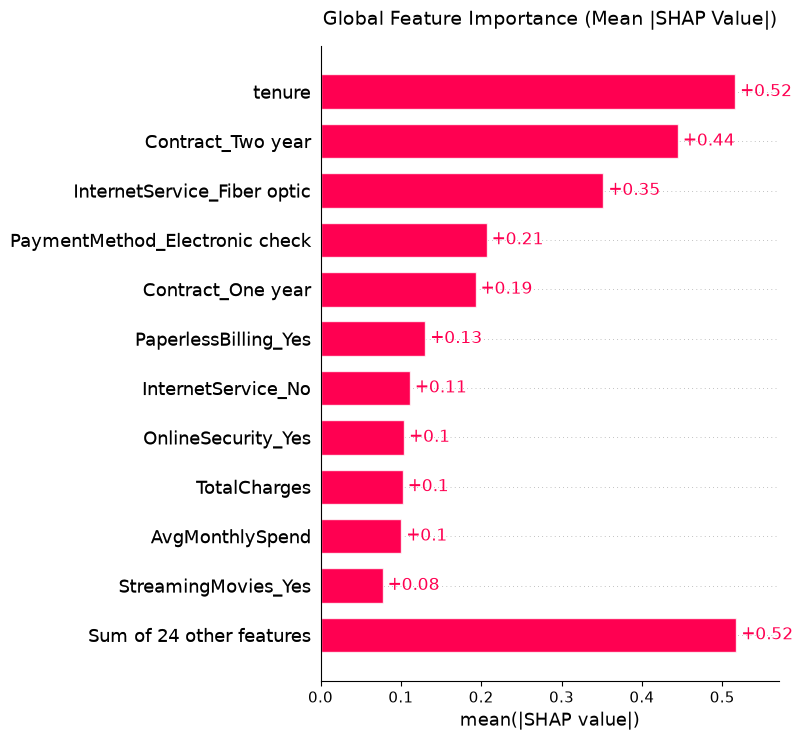

In [9]:
#global explainability- feature importance ranking
plt.figure(figsize=(10,6))
plt.title("Global Feature Importance (Mean |SHAP Value|)", fontsize=14, pad=15)
shap.plots.bar(shap_values,max_display=12, show=False)
plt.tight_layout()
plt.show()

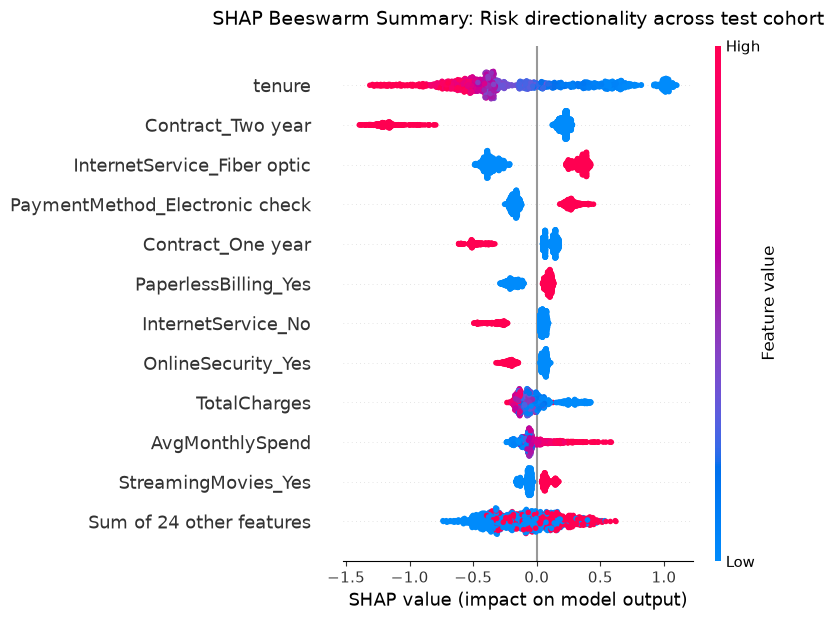

In [11]:
#global explainabilty- summary beeswarm plot
plt.figure(figsize=(12,8))
plt.title("SHAP Beeswarm Summary: Risk directionality across test cohort", fontsize=14,pad=15)
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

#red points- high feature value   blue points=low feature value
#position on x-axis=impact on log-odds of churning (+ = higher risk)

Selected customer index:38
Actual target: Churned(1)
Predicted Churn Probability: 83.40%


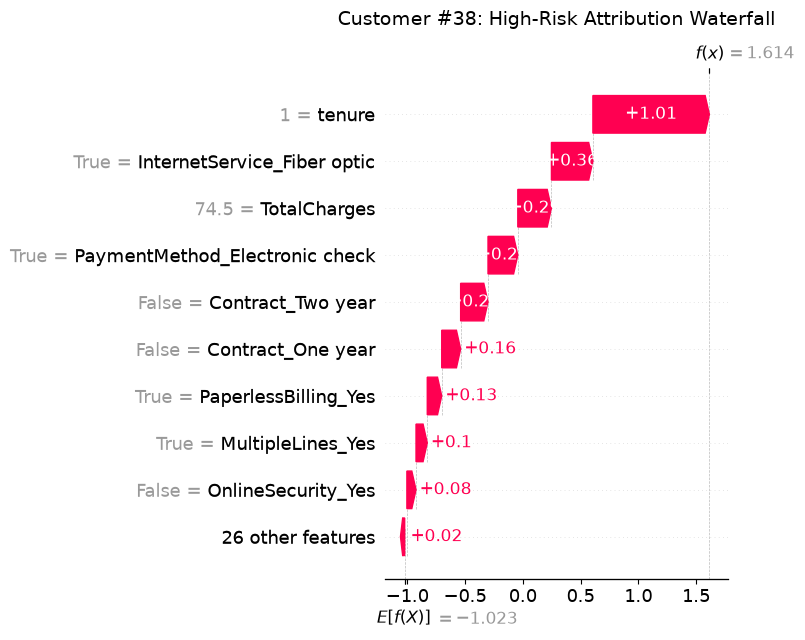

In [14]:
#local explainabilty-high risk churn case study
y_probs=model.predict_proba(X_test)[:,1] #compute predicted probabilities across the test set

#isolate high-risk accounts (prob>=0.75) who actually churned
high_risk_indices=np.where((y_probs>=0.75) & (y_test.values==1))[0]
sample_idx=high_risk_indices[0]
print(f"Selected customer index:{sample_idx}")
print(f"Actual target: Churned({y_test.iloc[sample_idx]})")
print(f"Predicted Churn Probability: {y_probs[sample_idx]:.2%}")

#generate waterfall plot- explains the move from base log-odds E[f(x)] to the final preditcion f(x)
plt.figure(figsize=(10,6))
shap.plots.waterfall(shap_values[sample_idx], max_display=10, show=False)
plt.title(f"Customer #{sample_idx}: High-Risk Attribution Waterfall", fontsize=14,pad=15)
plt.tight_layout()
plt.show()

Selected customer index: 0
Actual Target: Retained (0)
Predicted churn probability: 2.83%


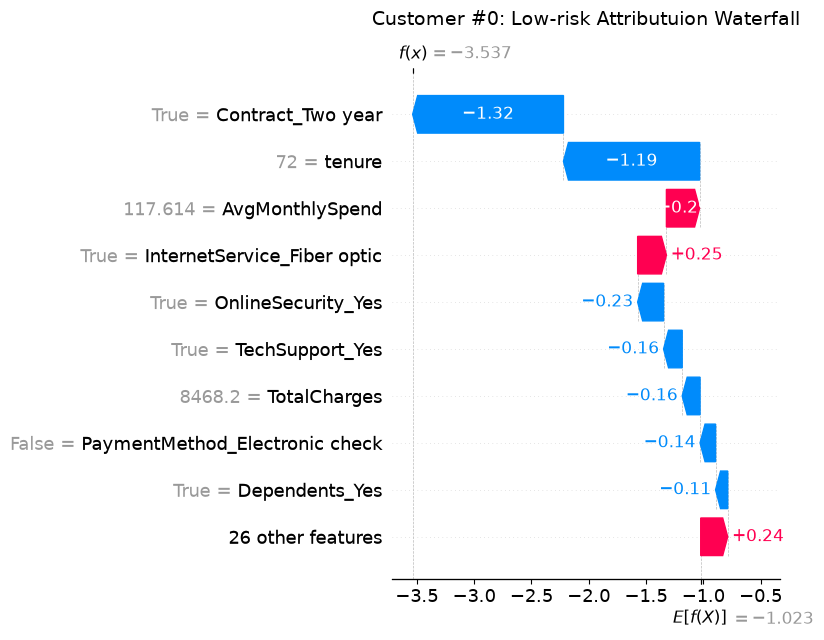

In [17]:
#local explainability- low-risk retained case study

#isolate retained customer accounts
low_risk_indices=np.where((y_probs<=0.10) & (y_test.values==0))[0]
retained_idx=low_risk_indices[0]
print(f"Selected customer index: {retained_idx}")
print(f"Actual Target: Retained ({y_test.iloc[retained_idx]})")
print(f"Predicted churn probability: {y_probs[retained_idx]:.2%}")

#generate waterfall plot for retained/loyal profile
plt.figure(figsize=(10,6))
shap.plots.waterfall(shap_values[retained_idx], max_display=10, show=False)
plt.title(f"Customer #{retained_idx}: Low-risk Attributuion Waterfall", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [20]:
#export explaination artifacts for the Streamlit App
joblib.dump(explainer,"../models/shap_explainer.pkl") #save the fitted TreeExplainer object

#save a customer sample record for quick testing
sample_customer=X_test.iloc[[sample_idx]]
sample_customer.to_csv("../data/sample_customer.csv", index=False)

print("Saved '..models/shap_explainer.pkl' and '../data/sample_customer.csv' successfully")

Saved '..models/shap_explainer.pkl' and '../data/sample_customer.csv' successfully
